# Decomposed EDR rechallenge

Plan 8 asks whether preserving the exact effective-information recursion and smoothing only movement risk repairs historical EDR. The answer is mixed but clear: the covariance decomposition is sound, the historical action inflation is reduced on the single lap, and the tested online movement estimator still fails as a predictive controller under reversals.

In [1]:
from pathlib import Path
import sys

repo_root = next(
    candidate
    for candidate in (Path.cwd(), *Path.cwd().parents)
    if (candidate / 'mnist_experiment' / 'plan8.md').is_file()
)
if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Markdown, display

from mnist_experiment.rotated_mnist.phase5_double_lap_artifacts import load_completed_double_lap_run
from mnist_experiment.rotated_mnist.phase5_single_lap_artifacts import load_completed_single_lap_run
from mnist_experiment.rotated_mnist.phase7_artifacts import load_completed_phase7_audit
from mnist_experiment.rotated_mnist.phase8_artifacts import load_completed_phase8_run

base = repo_root / 'cache' / 'mnist_experiment' / 'rotated_mnist'
single_source = load_completed_single_lap_run(base / 'phase5' / 'single_lap' / 'rotated_mnist_phase5_slow_single_lap_development__replica-0001__30f2161a06eb8d50')
double_source = load_completed_double_lap_run(base / 'phase5' / 'double_lap' / 'rotated_mnist_phase5_double_lap_development__replica-0001__e8d49d4599638493')
coefficient_audit = load_completed_phase7_audit(base / 'phase7' / 'coefficient_audit' / 'rotated_mnist_phase7_anchor_audit_primary_v3__replica-0001__4406a8e7634c0ad8')
single = load_completed_phase8_run(base / 'phase8' / 'single_lap' / 'rotated_mnist_phase8_single_lap_rechallenge__replica-0001__6445ab53bb10cd25')
double = load_completed_phase8_run(base / 'phase8' / 'double_lap' / 'rotated_mnist_phase8_double_lap_reversal_stress__replica-0001__f035d4b8cdf6d894')
print('Loaded completed, immutable Plan 5, Plan 7, and Plan 8 artifacts.')

Loaded completed, immutable Plan 5, Plan 7, and Plan 8 artifacts.


## Estimand and treatment

The applied fixed-batch covariance recursion is exact once the realized action is known:

$$q_{t+1}=(1-\pi_t)^2q_t+\frac{\pi_t^2}{m_t}, \qquad \pi_t^{\mathrm{cov},q}=\frac{m_tq_t}{1+m_tq_t}.$$

Decomposed EDR estimates only the normalized movement premium $\rho_t=m_tS_t/D_t$ and applies

$$\widehat\pi_t=\frac{\overline\rho_t+m_tq_t}{\overline\rho_t+m_tq_t+1}.$$

`tracked_q_covariance` sets the uncertain movement premium to zero. `decomposed_edr` adds its predictable, exponentially discounted estimate. Both actions govern the EWC objective and the direct-EMA Fisher update. No LFU is used.

In [2]:
provenance = pd.DataFrame([
    {
        'role': 'single-lap source',
        'run_id': single_source.config.run_id,
        'config hash': single_source.config.config_hash[:12],
        'm': single_source.config.data.samples_per_step,
        'updates / schedule': len(single_source.trajectory_metrics['linear']['fixed_pi005']) - 1,
    },
    {
        'role': 'single-lap rechallenge',
        'run_id': single.config.run_id,
        'config hash': single.config.config_hash[:12],
        'm': single.run_summary['samples_per_step'],
        'updates / schedule': len(single.trajectory_metrics['linear']['decomposed_edr']) - 1,
    },
    {
        'role': 'double-lap source',
        'run_id': double_source.config.run_id,
        'config hash': double_source.config.config_hash[:12],
        'm': double_source.config.data.samples_per_step,
        'updates / schedule': len(double_source.trajectory_metrics['linear']['fixed_pi005']) - 1,
    },
    {
        'role': 'double-lap rechallenge',
        'run_id': double.config.run_id,
        'config hash': double.config.config_hash[:12],
        'm': double.run_summary['samples_per_step'],
        'updates / schedule': len(double.trajectory_metrics['linear']['decomposed_edr']) - 1,
    },
])
display(provenance)
print('All Plan 8 runs used a 512-parameter CNN and rank-8-plus-diagonal Fisher summaries.')

,role,run_id,config hash,m,updates / schedule
0,single-lap source,rotated_mnist_phase5_slow_single_lap_developme...,30f2161a06eb,4,80
1,single-lap rechallenge,rotated_mnist_phase8_single_lap_rechallenge__r...,6445ab53bb10,4,80
2,double-lap source,rotated_mnist_phase5_double_lap_development__r...,e8d49d459963,4,120
3,double-lap rechallenge,rotated_mnist_phase8_double_lap_reversal_stres...,f035d4b8cdf6,4,120


All Plan 8 runs used a 512-parameter CNN and rank-8-plus-diagonal Fisher summaries.


## Covariance result inherited from Plan 7

The coefficient audit compared the matrix-free tracked-$q_t$ recommendation with a population covariance oracle. Its mean absolute discrepancy was below $.001$ on both schedules. The stationary $c/2$ expression was a useful approximation, not an actuated policy. Plan 8 therefore treats the covariance component as validated under the stated equal-shape calibration assumptions and tests the movement component separately.

In [3]:
audit_rows = pd.DataFrame(coefficient_audit.coefficient_rows)
primary = audit_rows[(audit_rows['condition'] == coefficient_audit.config.primary_condition) & (audit_rows['rank'] == coefficient_audit.config.primary_rank)].copy()
primary['tracked_q_pi'] = (coefficient_audit.config.deployed_batch_size * primary['q']) / (1 + coefficient_audit.config.deployed_batch_size * primary['q'])
covariance_rows = []
for schedule in coefficient_audit.config.schedule_kinds:
    data = primary[(primary['schedule'] == schedule) & ~primary['cold_start']]
    covariance_rows.append({
        'schedule': schedule,
        'MAE: tracked q': np.mean(np.abs(data['tracked_q_pi'] - data['covariance_only_pi'])),
        'MAE: stationary c/2': np.mean(np.abs(data['applied_pi'] / 2 - data['covariance_only_pi'])),
        'population movement lift': np.mean(data['centered_marginal_pi'] - data['covariance_only_pi']),
    })
display(pd.DataFrame(covariance_rows).style.format({column: '{:.4f}' for column in covariance_rows[0] if column != 'schedule'}))

,schedule,MAE: tracked q,MAE: stationary c/2,population movement lift
0,linear,0.0008,0.0094,0.0026
1,sigmoid,0.0009,0.0120,0.0026


## Realized actions

The single-lap decomposition reduces historical EDR's inflated action, but the estimated movement premium still dominates the low-noise covariance recommendation. The effect becomes unstable on the linear double lap. Vertical lines mark reversals.

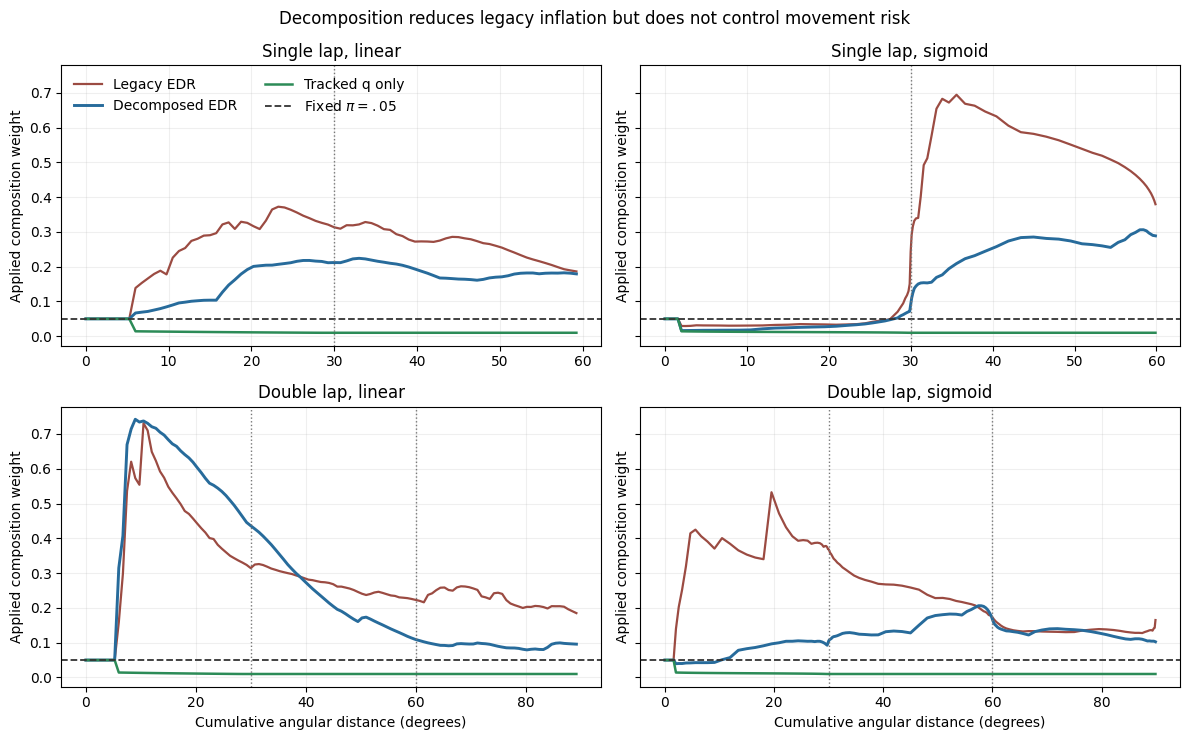

In [4]:
def controller_frame(rows):
    records = []
    for row in rows:
        if row['controller'] is None:
            continue
        records.append({
            'distance': row['cumulative_angular_degrees'],
            'angle': row['angle_degrees'],
            **row['controller'],
        })
    return pd.DataFrame(records)

fig, axes = plt.subplots(2, 2, figsize=(12, 7.5), sharey=True)
for column, schedule in enumerate(('linear', 'sigmoid')):
    old = controller_frame(single_source.trajectory_metrics[schedule]['edr_slowtrend_slowaction'])
    new = controller_frame(single.trajectory_metrics[schedule]['decomposed_edr'])
    cov = controller_frame(single.trajectory_metrics[schedule]['tracked_q_covariance'])
    axis = axes[0, column]
    axis.plot(old['distance'], old['applied_pi'], color='#9b4b42', linewidth=1.6, label='Legacy EDR')
    axis.plot(new['distance'], new['applied_pi'], color='#276b9b', linewidth=2.1, label='Decomposed EDR')
    axis.plot(cov['distance'], cov['applied_pi'], color='#2c8b57', linewidth=1.8, label='Tracked q only')
    axis.axhline(.05, color='#333333', linestyle='--', linewidth=1.3, label=r'Fixed $\pi=.05$')
    axis.axvline(30, color='#777777', linestyle=':', linewidth=1)
    axis.set_title(f'Single lap, {schedule}')
    axis.set_ylabel('Applied composition weight')

    old = controller_frame(double_source.trajectory_metrics[schedule]['edr_fasttrend_slowaction'])
    new = controller_frame(double.trajectory_metrics[schedule]['decomposed_edr'])
    cov = controller_frame(double.trajectory_metrics[schedule]['tracked_q_covariance'])
    axis = axes[1, column]
    axis.plot(old['distance'], old['applied_pi'], color='#9b4b42', linewidth=1.6, label='Legacy EDR')
    axis.plot(new['distance'], new['applied_pi'], color='#276b9b', linewidth=2.1, label='Decomposed EDR')
    axis.plot(cov['distance'], cov['applied_pi'], color='#2c8b57', linewidth=1.8, label='Tracked q only')
    axis.axhline(.05, color='#333333', linestyle='--', linewidth=1.3, label=r'Fixed $\pi=.05$')
    for reversal in (30, 60):
        axis.axvline(reversal, color='#777777', linestyle=':', linewidth=1)
    axis.set_title(f'Double lap, {schedule}')
    axis.set_xlabel('Cumulative angular distance (degrees)')
    axis.set_ylabel('Applied composition weight')
for axis in axes.flat:
    axis.grid(alpha=.2)
axes[0, 0].legend(ncol=2, frameon=False, loc='upper left')
fig.suptitle('Decomposition reduces legacy inflation but does not control movement risk')
fig.tight_layout()
plt.show()

## Upright-panel retention

Accuracy on the fixed $0^\circ$ panel isolates retention while the current environment rotates. The decomposed movement policy loses this retained capability most severely on the linear double lap.

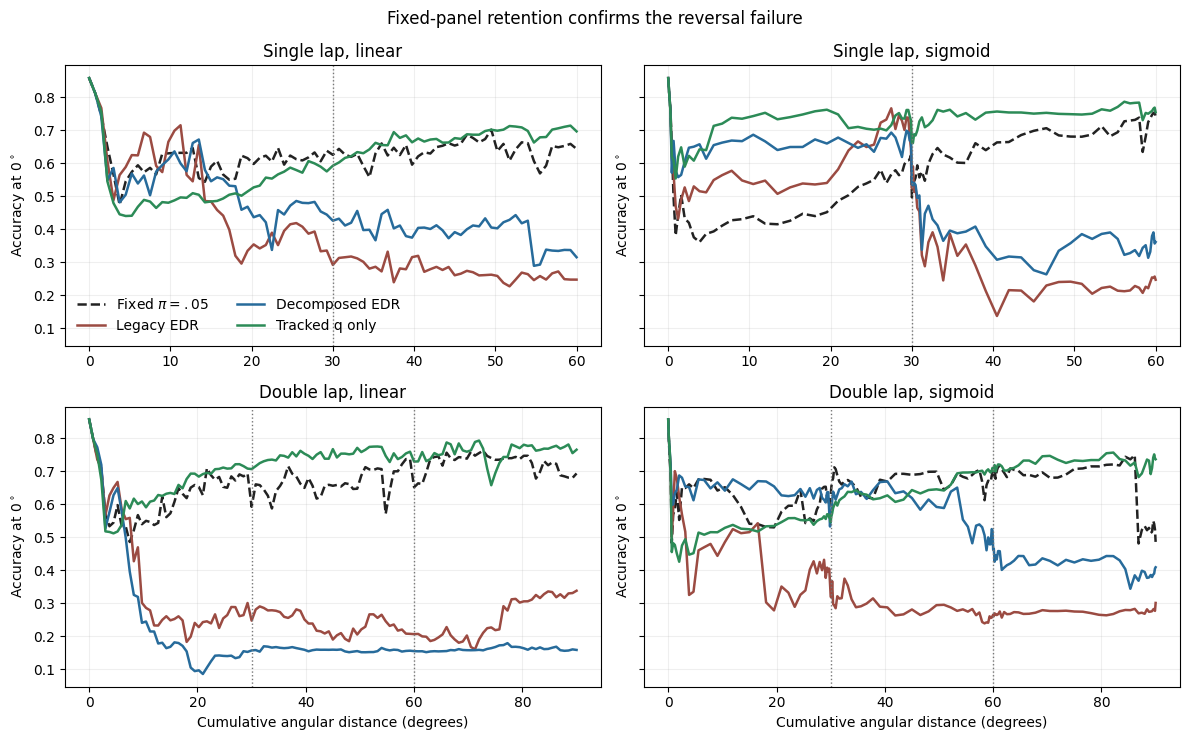

In [5]:
retention_styles = {
    'fixed': (r'Fixed $\pi=.05$', '#222222', '--'),
    'legacy': ('Legacy EDR', '#9b4b42', '-'),
    'decomposed': ('Decomposed EDR', '#276b9b', '-'),
    'covariance': ('Tracked q only', '#2c8b57', '-'),
}
fig, axes = plt.subplots(2, 2, figsize=(12, 7.5), sharey=True)
for row_index, (name, source_run, new_run, legacy_name) in enumerate((
    ('Single lap', single_source, single, 'edr_slowtrend_slowaction'),
    ('Double lap', double_source, double, 'edr_fasttrend_slowaction'),
)):
    for column, schedule in enumerate(('linear', 'sigmoid')):
        axis = axes[row_index, column]
        series = (
            ('fixed', source_run.trajectory_metrics[schedule]['fixed_pi005']),
            ('legacy', source_run.trajectory_metrics[schedule][legacy_name]),
            ('decomposed', new_run.trajectory_metrics[schedule]['decomposed_edr']),
            ('covariance', new_run.trajectory_metrics[schedule]['tracked_q_covariance']),
        )
        for style_name, rows in series:
            data = pd.DataFrame(rows)
            label, color, linestyle = retention_styles[style_name]
            axis.plot(data['cumulative_angular_degrees'], data['panel_000_environment_accuracy'], label=label, color=color, linestyle=linestyle, linewidth=1.8)
        reversals = (30,) if row_index == 0 else (30, 60)
        for reversal in reversals:
            axis.axvline(reversal, color='#777777', linestyle=':', linewidth=1)
        axis.set_title(f'{name}, {schedule}')
        axis.set_ylabel(r'Accuracy at $0^\circ$')
        axis.grid(alpha=.2)
        if row_index == 1:
            axis.set_xlabel('Cumulative angular distance (degrees)')
axes[0, 0].legend(ncol=2, frameon=False, loc='lower left')
fig.suptitle('Fixed-panel retention confirms the reversal failure')
fig.tight_layout()
plt.show()

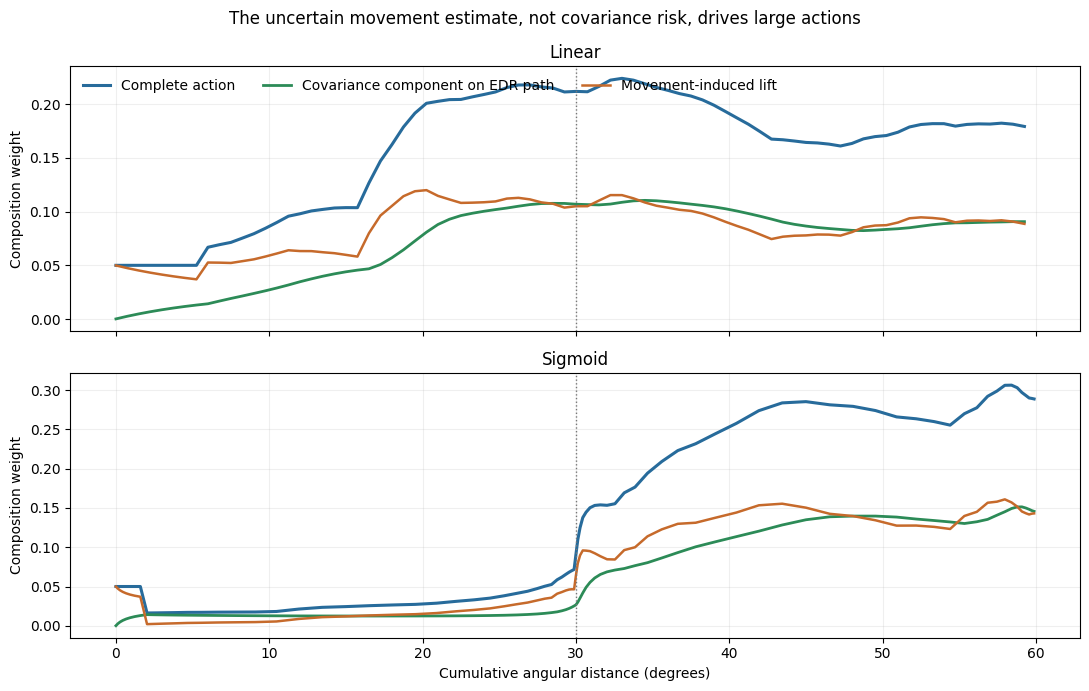

In [6]:
fig, axes = plt.subplots(2, 1, figsize=(11, 7), sharex=True)
for axis, schedule in zip(axes, ('linear', 'sigmoid'), strict=True):
    data = controller_frame(single.trajectory_metrics[schedule]['decomposed_edr'])
    data['movement_lift'] = data['applied_pi'] - data['covariance_only_pi']
    axis.plot(data['distance'], data['applied_pi'], color='#276b9b', linewidth=2.2, label='Complete action')
    axis.plot(data['distance'], data['covariance_only_pi'], color='#2c8b57', linewidth=2, label='Covariance component on EDR path')
    axis.plot(data['distance'], data['movement_lift'], color='#c66a2b', linewidth=1.8, label='Movement-induced lift')
    axis.axvline(30, color='#777777', linestyle=':', linewidth=1)
    axis.set_title(schedule.capitalize())
    axis.set_ylabel('Composition weight')
    axis.grid(alpha=.2)
axes[-1].set_xlabel('Cumulative angular distance (degrees)')
axes[0].legend(ncol=3, frameon=False, loc='upper left')
fig.suptitle('The uncertain movement estimate, not covariance risk, drives large actions')
fig.tight_layout()
plt.show()

## Predictive evidence

These are exactly paired development trajectories, not independent replicas. Their purpose is treatment diagnosis. Fixed $.05$ is prospective; fixed $.025$ was selected post facto and is not shown in the primary plots.

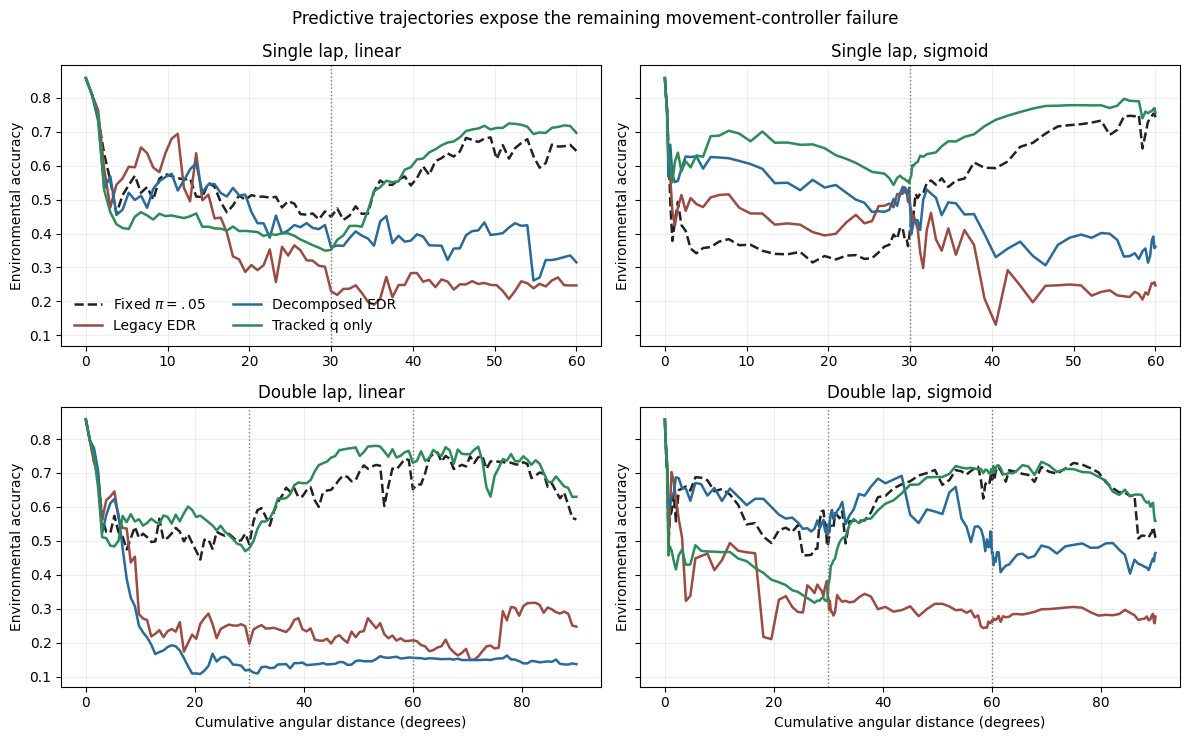

In [7]:
styles = {
    'fixed': (r'Fixed $\pi=.05$', '#222222', '--'),
    'legacy': ('Legacy EDR', '#9b4b42', '-'),
    'decomposed': ('Decomposed EDR', '#276b9b', '-'),
    'covariance': ('Tracked q only', '#2c8b57', '-'),
}
fig, axes = plt.subplots(2, 2, figsize=(12, 7.5), sharey=True)
for row_index, (name, source_run, new_run, legacy_name) in enumerate((
    ('Single lap', single_source, single, 'edr_slowtrend_slowaction'),
    ('Double lap', double_source, double, 'edr_fasttrend_slowaction'),
)):
    for column, schedule in enumerate(('linear', 'sigmoid')):
        axis = axes[row_index, column]
        series = (
            ('fixed', source_run.trajectory_metrics[schedule]['fixed_pi005']),
            ('legacy', source_run.trajectory_metrics[schedule][legacy_name]),
            ('decomposed', new_run.trajectory_metrics[schedule]['decomposed_edr']),
            ('covariance', new_run.trajectory_metrics[schedule]['tracked_q_covariance']),
        )
        for style_name, rows in series:
            data = pd.DataFrame(rows)
            label, color, linestyle = styles[style_name]
            axis.plot(data['cumulative_angular_degrees'], data['current_environment_accuracy'], label=label, color=color, linestyle=linestyle, linewidth=1.8)
        reversals = (30,) if row_index == 0 else (30, 60)
        for reversal in reversals:
            axis.axvline(reversal, color='#777777', linestyle=':', linewidth=1)
        axis.set_title(f'{name}, {schedule}')
        axis.set_ylabel('Environmental accuracy')
        axis.grid(alpha=.2)
        if row_index == 1:
            axis.set_xlabel('Cumulative angular distance (degrees)')
axes[0, 0].legend(ncol=2, frameon=False, loc='lower left')
fig.suptitle('Predictive trajectories expose the remaining movement-controller failure')
fig.tight_layout()
plt.show()

In [8]:
def comparison_table(source_run, new_run, legacy_name, design):
    records = []
    for schedule in ('linear', 'sigmoid'):
        summaries = {**source_run.run_summary['condition_summaries'][schedule], **new_run.run_summary['condition_summaries'][schedule]}
        for condition, label in ((
            ('fixed_pi005', r'Fixed $\pi=.05$'),
            (legacy_name, 'Legacy EDR'),
            ('tracked_q_covariance', 'Tracked q only'),
            ('decomposed_edr', 'Decomposed EDR'),
        )):
            value = summaries[condition]
            records.append({
                'design': design,
                'schedule': schedule,
                'condition': label,
                'accuracy AUC': value['environment_accuracy_auc'],
                'NLL AUC': value['environment_nll_auc'],
                'final upright accuracy': value['final_upright_environment_accuracy'],
                'final worst recall': value['final_worst_class_recall'],
            })
    return records

comparisons = pd.DataFrame(
    comparison_table(single_source, single, 'edr_slowtrend_slowaction', 'single lap')
    + comparison_table(double_source, double, 'edr_fasttrend_slowaction', 'double lap')
)
display(comparisons.style.format({
    'accuracy AUC': '{:.3f}',
    'NLL AUC': '{:.2f}',
    'final upright accuracy': '{:.3f}',
    'final worst recall': '{:.3f}',
}))

,design,schedule,condition,accuracy AUC,NLL AUC,final upright accuracy,final worst recall
0,single lap,linear,Fixed $\pi=.05$,0.563,2.72,0.643,0.334
1,single lap,linear,Legacy EDR,0.360,36.10,0.247,0.000
2,single lap,linear,Tracked q only,0.533,3.59,0.697,0.150
3,single lap,linear,Decomposed EDR,0.443,9.22,0.315,0.000
4,single lap,sigmoid,Fixed $\pi=.05$,0.520,3.79,0.743,0.238
5,single lap,sigmoid,Legacy EDR,0.397,30.54,0.247,0.000
6,single lap,sigmoid,Tracked q only,0.670,1.69,0.755,0.390
7,single lap,sigmoid,Decomposed EDR,0.483,7.71,0.361,0.000
8,double lap,linear,Fixed $\pi=.05$,0.631,2.72,0.694,0.308
9,double lap,linear,Legacy EDR,0.273,67.21,0.338,0.000


## Cost and operational checks

The new treatments recomputed every model, optimizer, Fisher, controller, and displacement state. The fixed-policy sentinel exactly reproduced the historical single-lap metrics; action and $q_t$ identities reconstruct to floating-point precision.

In [9]:
check_rows = []
for label, run in (('single lap', single), ('double lap', double)):
    checks = run.operational_checks
    check_rows.append({
        'design': label,
        'complete': checks['all_trajectories_complete'],
        'predictable': checks['all_decisions_predictable'],
        'finite': checks['all_finite'],
        'max action residual': checks['maximum_action_reconstruction_error'],
        'max q residual': checks['maximum_q_recursion_error'],
        'wall seconds': run.run_summary['total_wall_time_seconds'],
        'peak CUDA MiB': run.run_summary['peak_cuda_memory_bytes'] / 2**20,
    })
display(pd.DataFrame(check_rows).style.format({
    'max action residual': '{:.2e}',
    'max q residual': '{:.2e}',
    'wall seconds': '{:.1f}',
    'peak CUDA MiB': '{:.1f}',
}))

,design,complete,predictable,finite,max action residual,max q residual,wall seconds,peak CUDA MiB
0,single lap,True,True,True,5.55e-17,6.94e-18,238.8,72.8
1,double lap,True,True,True,2.78e-17,1.39e-17,237.4,72.5


## Evidence ledger

| Claim | Classification | Evidence |
|---|---|---|
| Tracked $q_t$ estimates covariance-only Fisher risk under equal local covariance shape. | Supported under stated assumptions | Plan 7 population-oracle MAE is below $.001$ on both schedules. |
| Separating covariance and movement repairs historical EDR coefficient mixing. | Supported mechanistically | Exact reconstruction passes; single-lap mean actions fall from $.277$ to $.171$ on linear and from $.300$ to $.145$ on sigmoid. |
| The tested movement estimator yields a competitive online policy. | Unsupported | Decomposed EDR trails prospective fixed $.05$ on both single-lap schedules and both double-lap schedules. |
| The tested controller responds favorably to path speed and reversals. | Contradicted | Sigmoid lagged speed/action association is negative; linear double-lap accuracy AUC falls below legacy EDR. |
| Covariance-only actuation can be useful. | Suggestive, schedule-dependent | It beats fixed $.05$ on single-lap sigmoid and double-lap linear, but loses on their paired schedules and mostly occupies the $.01$ floor. |
| Decomposed EDR improves adaptive Hybrid B32. | Untested by gate | EWC-only stress failure prevented Hybrid implementation. |
| Predictive effects generalize across independent initializations. | Unresolved | No treatment qualified for fresh confirmation; all Plan 8 predictive evidence is one paired development replica. |

The appropriate Plan 8 conclusion is **validated covariance decomposition, failed tested movement controller**. This narrows the research problem rather than invalidating the marginal-risk derivation: future work needs a movement estimator whose predictable signal is calibrated and responsive without reproducing anchor-error feedback.

## Proposed integration for review

No theory or project-level findings are changed in this phase. A later approved update should preserve the tracked-$q_t$ covariance result and stationary $c/2$ interpretation; identify the exponentially discounted movement premium as an empirically rejected controller implementation, not a theorem; retain adaptive composition as an open estimation problem; and avoid claiming adaptive Hybrid or independent predictive confirmation.